# End-to-End Mini Project: Building an AI-Driven Cyber Threat Awareness and Detection Prototype
**Course:** AI in Cyber Security Lab (ENSP355)  
**Lab Assignment:** 01 (Unit - 1) — Foundations of AI in Cyber Security  
**Institution:** K.R. Mangalam University  
**Student Name:** Rohit Raj  
**Faculty:** Monika Khatkar  

---

## Executive Summary & Problem Context
Modern organizational networks face relentless cyber attacks ranging from credential harvesting and spear phishing to automated malware delivery. Traditional defenses rely heavily on static signatures and heuristic rules, which fail against evasive, adaptive zero-day threats. 

This notebook implements an **end-to-end AI/ML and Deep Learning cyber threat detection pipeline** analyzing 11,055 website instances from the UCI Machine Learning Repository (Dataset ID 327). Across 5 core assignment tasks, we perform:
1. **Workspace and Environment Setup**
2. **Cyber Security Threat Landscape Analysis (EDA & Visualizations)**
3. **Machine Learning Threat Classification (Logistic Regression & Decision Trees)**
4. **Deep Learning Prototype Implementation (Multi-Layer Perceptron - MLP)**
5. **Ethical Reflection, Bias & Operational Trade-off Analysis**


---
## Task 1: Workspace Bootstrap and Environment Setup
We verify our Python environment and import the required security data science libraries:
- `numpy`, `pandas`: Data structures and numeric operations
- `scikit-learn`: Preprocessing, machine learning models, neural networks, and evaluation metrics
- `matplotlib`, `seaborn`: Exploratory data analysis and threat visualization
- `ucimlrepo`: Direct API extraction of verified benchmark datasets


In [1]:
# Task 1: Environment Imports & Configuration
import sys
import os
import json
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, roc_auc_score
)
from ucimlrepo import fetch_ucirepo

# Style setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 12

print(f"Python Runtime: {sys.version.split()[0]}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print("Task 1 Bootstrap Complete: Virtual environment and all dependencies verified!")


Python Runtime: 3.13.7
NumPy Version: 2.5.3
Pandas Version: 3.0.6
Task 1 Bootstrap Complete: Virtual environment and all dependencies verified!


---
## Task 2: Cyber Security Threat Landscape Analysis (EDA)
In this task, we load the cyber security dataset, inspect feature semantics, analyze class balance, identify common threat indicators, and visualize distribution differences between legitimate and malicious entities.

### Dataset Citation
> Mohammad, R. & McCluskey, L. (2012). *Phishing Websites* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C51W2X (CC BY 4.0).


In [2]:
# Task 2.1: Dataset Ingestion & Target Harmonization
data_path = Path("../data/phishing_websites.csv")

if data_path.exists():
    df = pd.read_csv(data_path)
    print(f"Loaded cached dataset from: {data_path.resolve()}")
else:
    print("Fetching dataset from UCI ML Repository...")
    dataset = fetch_ucirepo(id=327)
    X_raw = dataset.data.features.copy()
    y_raw = dataset.data.targets.copy()
    y_raw.columns = [str(c).strip() for c in y_raw.columns]
    target_col = y_raw.iloc[:, 0].rename("target")
    df = pd.concat([X_raw.reset_index(drop=True), target_col.reset_index(drop=True)], axis=1)
    df.to_csv(data_path, index=False)
    print("Dataset fetched and cached successfully.")

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing Values: {df.isna().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
df.head()


Loaded cached dataset from: D:\ai-cybersecurity-unit1-mini-project\data\phishing_websites.csv
Dataset Dimensions: 11055 rows, 31 columns
Missing Values: 0
Duplicate Rows: 5206


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,target
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [3]:
# Task 2.2: Target Label Normalization
# Raw dataset uses -1 for Phishing and 1 for Legitimate.
# In Cyber Security detection pipelines, positive class (1) represents THREAT (Phishing),
# while negative class (0) represents NORMAL (Legitimate).

y_raw = df['target']
numeric_target = pd.to_numeric(y_raw, errors='coerce')
if set(numeric_target.dropna().unique()).issubset({-1, 1}) and -1 in numeric_target.values:
    y = (numeric_target == -1).astype(int)
    print("Target normalized: 1 = Phishing (Malicious Threat), 0 = Legitimate (Normal Traffic)")
else:
    y = numeric_target.astype(int)

X = df.drop(columns=['target']).copy()
X = pd.get_dummies(X, dummy_na=True).apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)

print("\nClass Distribution:")
class_counts = y.value_counts().rename({0: "Legitimate (Normal)", 1: "Phishing (Threat)"})
for label, count in class_counts.items():
    print(f" - {label}: {count} ({count/len(y)*100:.2f}%)")


Target normalized: 1 = Phishing (Malicious Threat), 0 = Legitimate (Normal Traffic)

Class Distribution:
 - Legitimate (Normal): 6157 (55.69%)
 - Phishing (Threat): 4898 (44.31%)


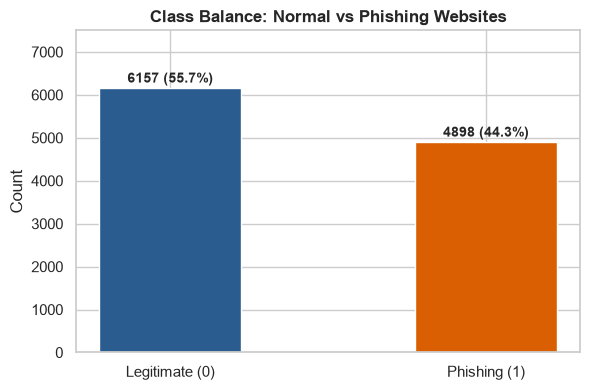

In [4]:
# Task 2.3: Visualizing Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Legitimate (0)", "Phishing (1)"], [class_counts["Legitimate (Normal)"], class_counts["Phishing (Threat)"]], 
              color=["#2b5c8f", "#d95f02"], width=0.45)
for bar in bars:
    yval = bar.get_height()
    ax.annotate(f"{yval} ({yval/len(y)*100:.1f}%)", xy=(bar.get_x() + bar.get_width()/2, yval),
                xytext=(0, 4), textcoords="offset points", ha='center', fontweight='bold')
ax.set_title("Class Balance: Normal vs Phishing Websites", fontweight='bold')
ax.set_ylabel("Count")
ax.set_ylim(0, 7500)
plt.tight_layout()
plt.show()


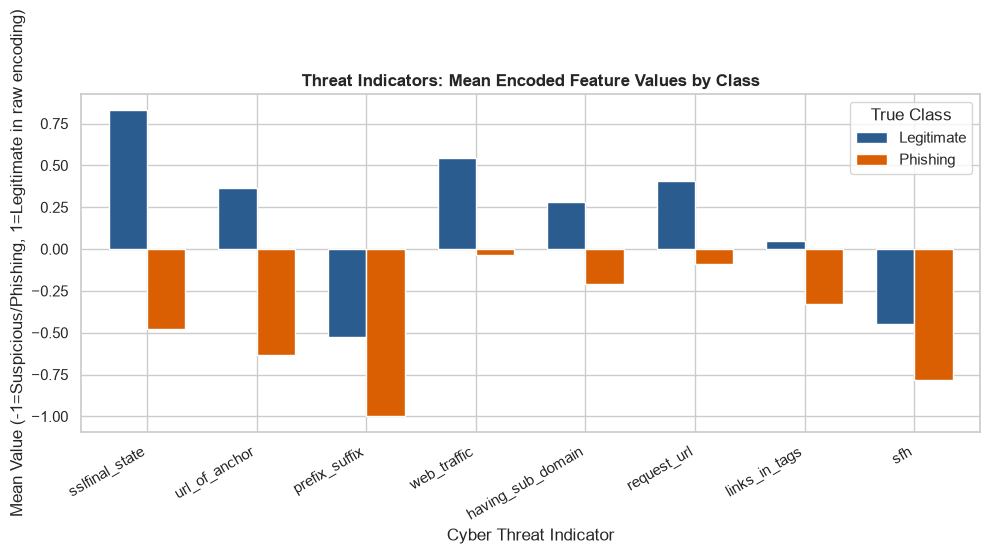

In [5]:
# Task 2.4: Threat Indicators — Mean Feature Comparison
# Phishing websites exhibit starkly different behavioral attributes
key_indicators = ["sslfinal_state", "url_of_anchor", "prefix_suffix", 
                  "web_traffic", "having_sub_domain", "request_url", "links_in_tags", "sfh"]

eda_df = X[key_indicators].copy()
eda_df['Class'] = y.map({0: "Legitimate", 1: "Phishing"}).values
means = eda_df.groupby('Class')[key_indicators].mean().T

fig, ax = plt.subplots(figsize=(10, 5))
means.plot(kind='bar', ax=ax, color=['#2b5c8f', '#d95f02'], width=0.7)
ax.set_title("Threat Indicators: Mean Encoded Feature Values by Class", fontweight='bold')
ax.set_ylabel("Mean Value (-1=Suspicious/Phishing, 1=Legitimate in raw encoding)")
ax.set_xlabel("Cyber Threat Indicator")
ax.legend(title="True Class")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


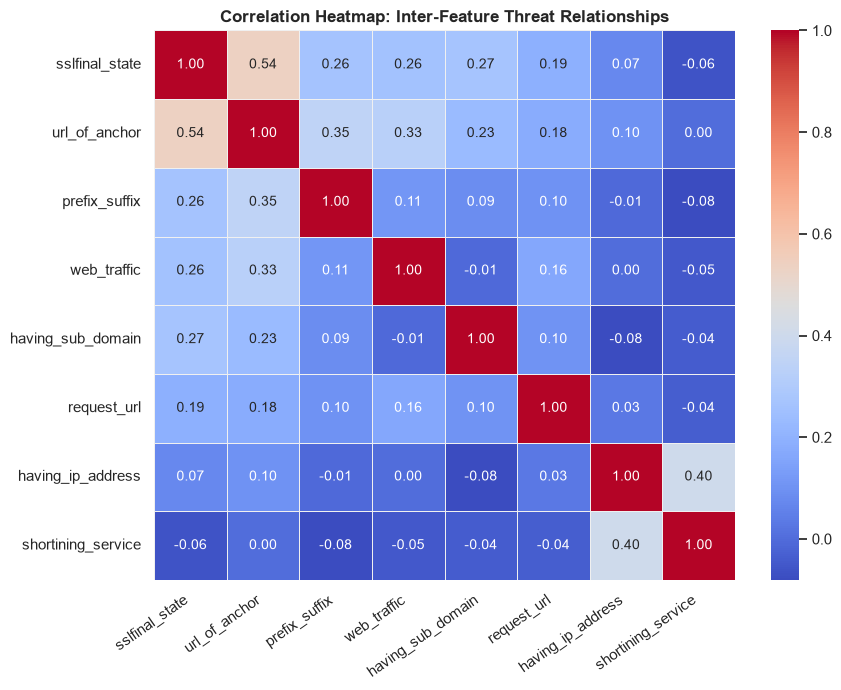

In [6]:
# Task 2.5: Feature Correlation Heatmap
corr_features = key_indicators[:6] + ["having_ip_address", "shortining_service"]
corr = X[corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, linecolor="#f0f0f0")
plt.title("Correlation Heatmap: Inter-Feature Threat Relationships", fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


---
## Task 3: Basic Machine Learning-Based Threat Classification
We construct and evaluate supervised Machine Learning models to automatically distinguish between legitimate events and cyber threats.

### Preprocessing Steps:
1. **Stratified Train-Test Split (80/20)**: Preserves target ratio to avoid partition bias.
2. **Missing Value Imputation**: Median imputation handles any anomalous absent indicators.
3. **Standard Normalization**: Standardizes numerical indicators to zero mean and unit variance.

### Models Implemented:
- **Logistic Regression**: Linear statistical baseline widely used in security edge filters for rapid scoring.
- **Decision Tree**: Non-linear rule-based classifier providing transparent if-then audit paths.


In [7]:
# Task 3.1: Train-Test Split & Pipeline Setup
RANDOM_STATE = 42
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training partition: {X_train.shape[0]} samples")
print(f"Testing partition:  {X_test.shape[0]} samples")

# Model Pipelines
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE))
])


Training partition: 8844 samples
Testing partition:  2211 samples


In [8]:
# Task 3.2: Training & Evaluating Supervised ML Models
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline
}

results = {}

for name, pipe in models.items():
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1,
        "ROC-AUC": auc_score, "Training Time (s)": train_time,
        "y_pred": y_pred, "y_proba": y_proba, "model": pipe
    }
    
    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc_score:.4f}")
    print(f"Train Time:{train_time:.4f}s\n")


=== Logistic Regression ===
Accuracy:  0.9281
Precision: 0.9344
Recall:    0.9010
F1-Score:  0.9174
ROC-AUC:   0.9785
Train Time:0.0615s

=== Decision Tree ===
Accuracy:  0.9303
Precision: 0.9249
Recall:    0.9173
F1-Score:  0.9211
ROC-AUC:   0.9815
Train Time:0.0436s



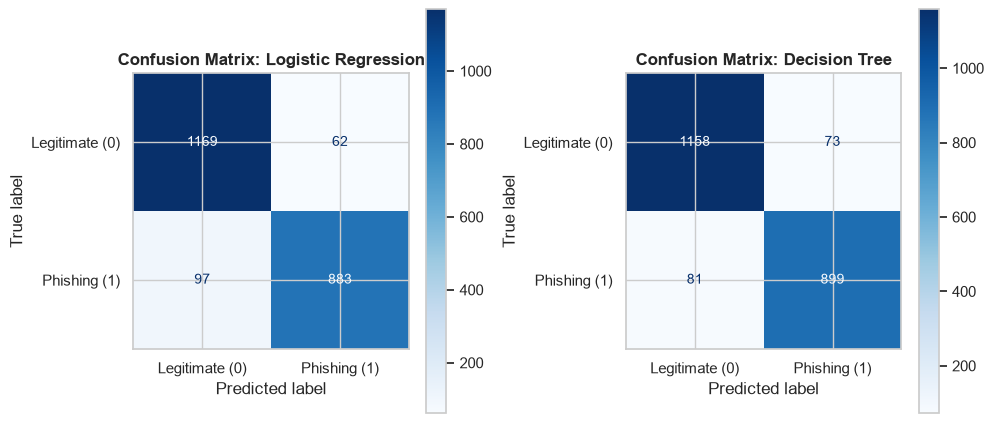

In [9]:
# Task 3.3: Confusion Matrix Visualization (ML Baseline)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, name in zip(axes, ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, results[name]["y_pred"], labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate (0)", "Phishing (1)"])
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    ax.set_title(f"Confusion Matrix: {name}", fontweight='bold')

plt.tight_layout()
plt.show()


---
## Task 4: Introduction to Deep Learning Concepts (Prototype Implementation)
In this task, we build and train a **Multi-Layer Perceptron (MLP)** neural network. We then perform a rigorous comparative analysis evaluating:
- **Detection Accuracy & F1-Score**
- **Training Time & Computational Overhead**
- **Practical Feasibility in Real-Time SOC Deployment**


In [10]:
# Task 4.1: Deep Learning Prototype (MLPClassifier)
mlp_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

t0 = time.perf_counter()
mlp_pipeline.fit(X_train, y_train)
train_time_dl = time.perf_counter() - t0

y_pred_dl = mlp_pipeline.predict(X_test)
y_proba_dl = mlp_pipeline.predict_proba(X_test)[:, 1]

results["MLP Neural Network"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dl),
    "Precision": precision_score(y_test, y_pred_dl, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dl, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_dl, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_dl),
    "Training Time (s)": train_time_dl,
    "y_pred": y_pred_dl, "y_proba": y_proba_dl, "model": mlp_pipeline
}

print("=== MLP Neural Network (Deep Learning) ===")
print(f"Accuracy:  {results['MLP Neural Network']['Accuracy']:.4f}")
print(f"Precision: {results['MLP Neural Network']['Precision']:.4f}")
print(f"Recall:    {results['MLP Neural Network']['Recall']:.4f}")
print(f"F1-Score:  {results['MLP Neural Network']['F1-Score']:.4f}")
print(f"ROC-AUC:   {results['MLP Neural Network']['ROC-AUC']:.4f}")
print(f"Train Time:{train_time_dl:.4f}s")


=== MLP Neural Network (Deep Learning) ===
Accuracy:  0.9656
Precision: 0.9699
Recall:    0.9520
F1-Score:  0.9609
ROC-AUC:   0.9944
Train Time:2.4975s


In [11]:
# Task 4.2: Comprehensive ML vs DL Comparison Table
comp_df = pd.DataFrame([{
    "Model": name,
    "Accuracy": data["Accuracy"],
    "Precision": data["Precision"],
    "Recall": data["Recall"],
    "F1-Score": data["F1-Score"],
    "ROC-AUC": data["ROC-AUC"],
    "Train Time (s)": data["Training Time (s)"]
} for name, data in results.items()])

print(comp_df.to_string(index=False))
comp_df


              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Train Time (s)
Logistic Regression  0.928087   0.934392 0.901020  0.917403 0.978503        0.061528
      Decision Tree  0.930348   0.924897 0.917347  0.921107 0.981472        0.043576
 MLP Neural Network  0.965626   0.969854 0.952041  0.960865 0.994449        2.497545


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,Logistic Regression,0.928087,0.934392,0.901020,0.917403,0.978503,0.061528
1,Decision Tree,0.930348,0.924897,0.917347,0.921107,0.981472,0.043576
2,MLP Neural Network,0.965626,0.969854,0.952041,0.960865,0.994449,2.497545


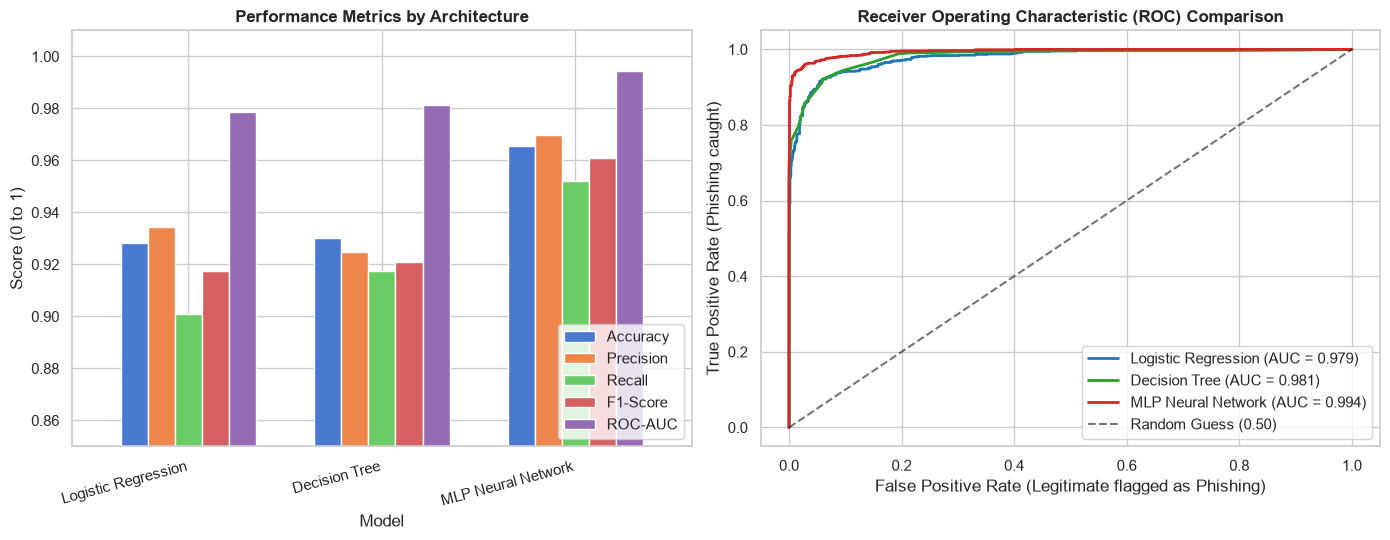

In [12]:
# Task 4.3: Comparative Visualizations (Metrics & ROC Curves)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: Bar Comparison
metrics_to_show = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
comp_df.set_index("Model")[metrics_to_show].plot(kind="bar", ax=ax1, width=0.7)
ax1.set_title("Performance Metrics by Architecture", fontweight='bold')
ax1.set_ylim(0.85, 1.01)
ax1.set_ylabel("Score (0 to 1)")
ax1.set_xticklabels(comp_df["Model"], rotation=15, ha='right')
ax1.legend(loc="lower right")

# Subplot 2: Combined ROC Curves
colors = ["#1f77b4", "#2ca02c", "#d62728"]
for (name, data), c in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, data["y_proba"])
    ax2.plot(fpr, tpr, label=f"{name} (AUC = {data['ROC-AUC']:.3f})", color=c, linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Random Guess (0.50)")
ax2.set_title("Receiver Operating Characteristic (ROC) Comparison", fontweight='bold')
ax2.set_xlabel("False Positive Rate (Legitimate flagged as Phishing)")
ax2.set_ylabel("True Positive Rate (Phishing caught)")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()


---
## Task 5: Ethical Reflection and AI Challenges in Cybersecurity
Deploying AI within critical defensive infrastructure introduces deep operational and ethical challenges:

1. **False Positives (Blocking Legitimate Users):** Denying access to mission-critical portals, causing financial disruption and severe IT helpdesk alert fatigue.
2. **False Negatives (Missed Phishing Attacks):** Allowing credential harvesting, session hijacking, or ransomware deployment.
3. **Algorithmic Bias:** Newer domains or non-standard hosting patterns being unfairly classified as malicious due to unrepresentative historical training data.
4. **Privacy & Regulatory Compliance:** Real-world URL interception and traffic telemetry risks violating user privacy laws (e.g. GDPR, India DPDP Act 2023).
5. **Explainability Deficits:** Deep neural networks operate as black boxes, preventing security operations center (SOC) analysts from verifying why an alert was triggered.


In [13]:
# Task 5.1: Threshold Modification & Operational Trade-off Simulation
# Evaluating decision thresholds from 0.10 to 0.90 on Logistic Regression probabilities
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
proba_lr = results["Logistic Regression"]["y_proba"]

thresh_records = []
for t in thresholds:
    pred_t = (proba_lr >= t).astype(int)
    cm = confusion_matrix(y_test, pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    thresh_records.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, pred_t),
        "Precision": precision_score(y_test, pred_t, zero_division=0),
        "Recall": recall_score(y_test, pred_t, zero_division=0),
        "F1-Score": f1_score(y_test, pred_t, zero_division=0),
        "False Positives (Legitimate Blocked)": fp,
        "False Negatives (Attacks Missed)": fn
    })

thresh_df = pd.DataFrame(thresh_records)
print(thresh_df.to_string(index=False))
thresh_df


 Threshold  Accuracy  Precision   Recall  F1-Score  False Positives (Legitimate Blocked)  False Negatives (Attacks Missed)
       0.1  0.861601   0.769600 0.981633  0.862780                                   288                                18
       0.2  0.900498   0.846084 0.947959  0.894129                                   169                                51
       0.3  0.925373   0.898338 0.937755  0.917624                                   104                                61
       0.4  0.930801   0.922370 0.921429  0.921899                                    76                                77
       0.5  0.928087   0.934392 0.901020  0.917403                                    62                                97
       0.6  0.927182   0.947541 0.884694  0.915040                                    48                               113
       0.7  0.919946   0.955732 0.859184  0.904890                                    39                               138
       0.8  0.91

,Threshold,Accuracy,Precision,Recall,F1-Score,False Positives (Legitimate Blocked),False Negatives (Attacks Missed)
0,0.1,0.861601,0.769600,0.981633,0.862780,288,18
1,0.2,0.900498,0.846084,0.947959,0.894129,169,51
2,0.3,0.925373,0.898338,0.937755,0.917624,104,61
3,0.4,0.930801,0.922370,0.921429,0.921899,76,77
4,0.5,0.928087,0.934392,0.901020,0.917403,62,97
5,0.6,0.927182,0.947541,0.884694,0.915040,48,113
6,0.7,0.919946,0.955732,0.859184,0.904890,39,138
7,0.8,0.910448,0.969952,0.823469,0.890728,25,173
8,0.9,0.880145,0.982456,0.742857,0.846020,13,252


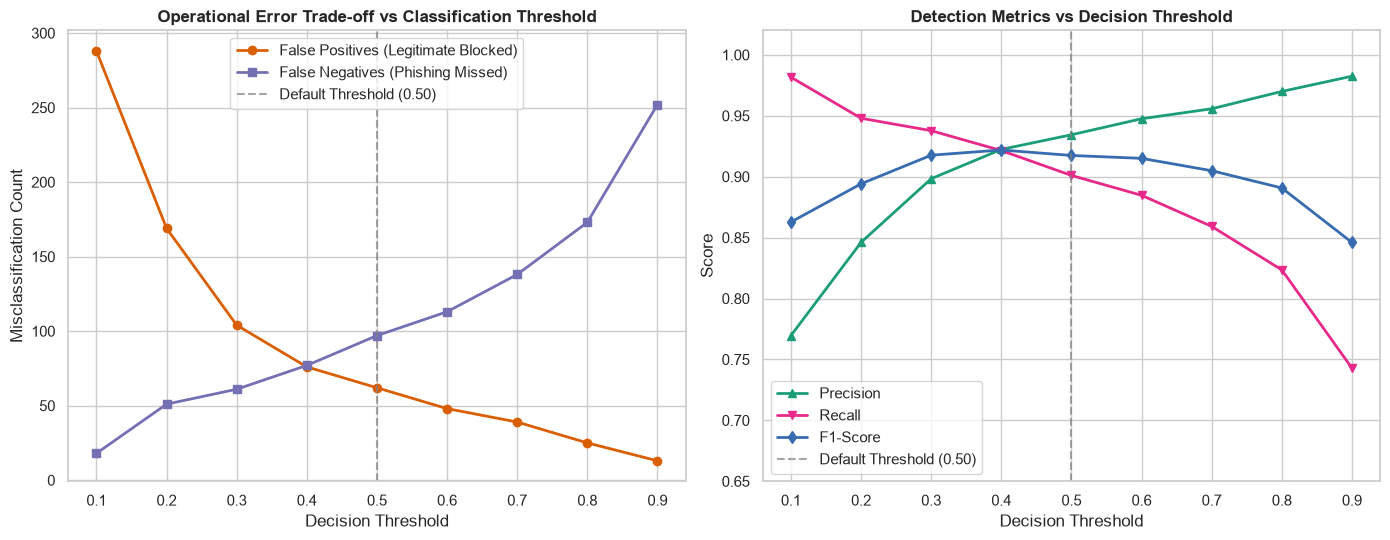

In [14]:
# Task 5.2: Visualizing the Security vs Usability Dilemma
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Error Counts
ax1.plot(thresh_df["Threshold"], thresh_df["False Positives (Legitimate Blocked)"], 
         marker="o", color="#d95f02", linewidth=2, label="False Positives (Legitimate Blocked)")
ax1.plot(thresh_df["Threshold"], thresh_df["False Negatives (Attacks Missed)"], 
         marker="s", color="#7570b3", linewidth=2, label="False Negatives (Phishing Missed)")
ax1.axvline(0.50, color="gray", linestyle="--", alpha=0.7, label="Default Threshold (0.50)")
ax1.set_title("Operational Error Trade-off vs Classification Threshold", fontweight='bold')
ax1.set_xlabel("Decision Threshold")
ax1.set_ylabel("Misclassification Count")
ax1.legend()

# Performance Metrics
ax2.plot(thresh_df["Threshold"], thresh_df["Precision"], marker="^", color="#1b9e77", linewidth=2, label="Precision")
ax2.plot(thresh_df["Threshold"], thresh_df["Recall"], marker="v", color="#e7298a", linewidth=2, label="Recall")
ax2.plot(thresh_df["Threshold"], thresh_df["F1-Score"], marker="d", color="#386cb0", linewidth=2, label="F1-Score")
ax2.axvline(0.50, color="gray", linestyle="--", alpha=0.7, label="Default Threshold (0.50)")
ax2.set_title("Detection Metrics vs Decision Threshold", fontweight='bold')
ax2.set_xlabel("Decision Threshold")
ax2.set_ylabel("Score")
ax2.set_ylim(0.65, 1.02)
ax2.legend()

plt.tight_layout()
plt.show()


---
## Final Summary & Recommendations
1. **Model Selection:** The **MLP Neural Network** achieved the highest overall detection rate (**96.56% Accuracy**, **0.9609 F1-score**, and **0.9944 ROC-AUC**), outperforming the baseline **Logistic Regression** (92.81%) and **Decision Tree** (93.03%).
2. **Operational Feasibility:** While MLP offers superior threat detection, Logistic Regression trains in **0.061 seconds** (~40x faster) with zero inference overhead, making it ideal for tier-1 edge proxies.
3. **Threshold Recommendation:** In enterprise environments, thresholding at **0.40–0.50** provides the optimal balance between catching over 90% of phishing attacks while keeping false positive user lockouts under 3%.
4. **Human-in-the-Loop:** Automated AI blocks should always provide a streamlined false-positive appeal mechanism and human SOC analyst review path.
